
# Predicting Credit Card Default Payments

### Phase 1 Report - Data Pre-processing and Data Exploration & Visualisation




**Group: Group 35**

| No. | Student Name | Student ID |
|-----|-------------|------------|
| 1   | Nikhila M   |  S4087528  |
| 2   | Aiswarya Sudhir | S4084978 |
| 3   | Rajan Vipulkumar Patel | S4113210 |

## Table of Contents

1. Introduction  
   - 1.1 Dataset Source  
   - 1.2 Dataset Details  
   - 1.3 Dataset Features  
   - 1.4 Target Feature  
2. Goals & Objectives  
3. Data Cleaning & Preprocessing
   - 3.1 Dropping ID-like Columns
   - 3.2 Checking for Missing Values
   - 3.3 Checking for Duplicate Records
   - 3.4 Handling Undocumented Category Values
   - 3.5 Recoding Categorical Variables
   - 3.6 Checking for Incorrect Values
4. Data Exploration & Visualisation  
   - 4.1 One-Variable Plots
   - 4.2 Two-Variable Plots
   - 4.3 Three-Variable Plots
5. Literature Review
6. Summary & Conclusions  
7. References


# 1. Introduction
Managing credit risk is one of the biggest challenges banks and financial
institutions face today. Being able to tell in advance which customers are likely to miss their credit card payments helps banks limit their losses, make smarter lending decisions, and look after both the business and its customers. Machine learning has become an increasingly useful way to tackle this problem, as it can detect complex patterns in large datasets that traditional methods might miss.
In this project, we use supervised machine learning on the UCI Default of Credit Card Clients Dataset to predict whether a customer will default on their next payment. The dataset is particularly well-suited for this task as it contains a diverse range of features covering customer demographics, financial history, and past payment behaviour.






## 1.1 Dataset Source

The dataset used in this project is the **Default of Credit Card Clients Dataset**, which was downloaded from Kaggle and is originally sourced from the UCI Machine Learning Repository (UCI ML, n.d.; Dua & Graff, 2019). It contains information about credit card clients in Taiwan and is commonly used for classification problems involving financial risk prediction. The dataset includes demographic information, credit limit, repayment history, bill statements, previous payments, and the default status for the following month.

This dataset was selected because it represents a realistic and business-relevant supervised machine learning problem. Predicting whether a customer will default on their credit card payment is important for banks and financial institutions, as it supports better risk management, lending decisions, and customer credit assessment.

The dataset was originally associated with the study by Yeh and Lien (2009), who compared data mining techniques for predicting credit card default probability. For this project, the downloadable version used was obtained from Kaggle, while the original repository source is UCI.

Dataset sources:

- Kaggle (downloaded dataset used in this project):
- https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
- UCI Machine Learning Repository (original source): https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
UCI_Credit_Card = pd.read_csv('Phase1_Group35.csv')

UCI_Credit_Card.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,0,0,64400.0,57069.0,57608.0,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,0,0,367965.0,412023.0,445007.0,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,0,-1,11876.0,380.0,601.0,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,0,0,11285.0,14096.0,12108.0,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,-1,-1,0.0,0.0,0.0,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


## 1.2 Dataset Details

The dataset used in this project is the *Default of Credit Card Clients Dataset*, available from the UCI Machine Learning Repository (Dua & Graff, 2019). It contains information about credit card clients in Taiwan and is commonly used for classification problems involving financial risk prediction. The dataset includes demographic information, credit limit, repayment history, bill statements, previous payments, and the default status for the following month.

This dataset was selected because it represents a realistic and business-relevant supervised machine learning problem. Predicting whether a customer will default on their credit card payment is important for banks and financial institutions, as it supports better risk management and lending decisions.

The dataset was originally associated with the work of Yeh and Lien (2009), who compared data mining techniques for predicting default probability. It is publicly accessible through the UCI Machine Learning Repository and mirrored on Kaggle.

- **Number of observations (rows):** 30,000
- **Number of features (columns):** 25 (including the ID column and the target variable)
- **Problem type:** Binary classification

To better understand the structure of the dataset, 10 random observations are displayed below. This helps verify the types of information available and confirms that the dataset contains a mix of numeric and categorical-style features.

In [2]:
print("Dataset shape:", UCI_Credit_Card.shape)
print("\nColumn names:")
print(UCI_Credit_Card.columns.tolist())

print("\n10 random observations:")
UCI_Credit_Card.sample(10, random_state=42)

Dataset shape: (30000, 25)

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']

10 random observations:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
2308,2309,30000.0,1,2,2,25,0,0,0,0,0,0,8864.0,10062.0,11581.0,12580.0,13716.0,14828.0,1500.0,2000.0,1500.0,1500.0,1500.0,2000.0,0
22404,22405,150000.0,2,1,2,26,0,0,0,0,0,0,136736.0,125651.0,116684.0,101581.0,77741.0,77264.0,4486.0,4235.0,3161.0,2647.0,2669.0,2669.0,0
23397,23398,70000.0,2,3,1,32,0,0,0,0,0,0,70122.0,69080.0,68530.0,69753.0,70111.0,70212.0,2431.0,3112.0,3000.0,2438.0,2500.0,2554.0,0
25058,25059,130000.0,1,3,2,49,0,0,0,0,0,-1,20678.0,18956.0,16172.0,16898.0,11236.0,6944.0,1610.0,1808.0,7014.0,27.0,7011.0,4408.0,0
2664,2665,50000.0,2,2,2,36,0,0,0,0,0,2,94228.0,47635.0,42361.0,19574.0,20295.0,19439.0,2000.0,1500.0,1000.0,1800.0,0.0,1000.0,1
8511,8512,50000.0,2,2,2,29,-1,-1,-1,0,0,0,1303.0,801.0,11512.0,11512.0,8490.0,0.0,801.0,11512.0,0.0,0.0,0.0,950.0,0
5148,5149,110000.0,1,3,2,33,1,2,0,0,0,-2,7128.0,1852.0,2625.0,2625.0,0.0,0.0,0.0,1000.0,0.0,0.0,0.0,0.0,1
7790,7791,140000.0,2,1,1,32,1,-2,-2,-2,-2,-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
11311,11312,260000.0,2,2,3,38,-1,-1,-1,-1,-1,0,8000.0,8000.0,8000.0,8000.0,24406.0,18043.0,8000.0,8000.0,8000.0,24406.0,2000.0,389.0,0
19043,19044,80000.0,2,2,2,23,0,0,-2,-2,-2,-2,68850.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## 1.3 Dataset Features

| Feature   | Data type           | Units                | Brief description                    |
| --------- | ------------------- | -------------------- | ------------------------------------ |
| LIMIT_BAL | Numeric             | NT dollars           | Amount of given credit               |
| SEX       | Binary categorical  | NA                   | Gender of the client                 |
| EDUCATION | Nominal categorical | NA                   | Education level                      |
| MARRIAGE  | Nominal categorical | NA                   | Marital status                       |
| AGE       | Numeric             | Years                | Age of the client                    |
| PAY_0     | Ordinal categorical | Months / status code | Repayment status in September        |
| PAY_2     | Ordinal categorical | Months / status code | Repayment status in August           |
| PAY_3     | Ordinal categorical | Months / status code | Repayment status in July             |
| PAY_4     | Ordinal categorical | Months / status code | Repayment status in June             |
| PAY_5     | Ordinal categorical | Months / status code | Repayment status in May              |
| PAY_6     | Ordinal categorical | Months / status code | Repayment status in April            |
| BILL_AMT1 | Numeric             | NT dollars           | Bill statement amount in September   |
| BILL_AMT2 | Numeric             | NT dollars           | Bill statement amount in August      |
| BILL_AMT3 | Numeric             | NT dollars           | Bill statement amount in July        |
| BILL_AMT4 | Numeric             | NT dollars           | Bill statement amount in June        |
| BILL_AMT5 | Numeric             | NT dollars           | Bill statement amount in May         |
| BILL_AMT6 | Numeric             | NT dollars           | Bill statement amount in April       |
| PAY_AMT1  | Numeric             | NT dollars           | Previous payment amount in September |
| PAY_AMT2  | Numeric             | NT dollars           | Previous payment amount in August    |
| PAY_AMT3  | Numeric             | NT dollars           | Previous payment amount in July      |
| PAY_AMT4  | Numeric             | NT dollars           | Previous payment amount in June      |
| PAY_AMT5  | Numeric             | NT dollars           | Previous payment amount in May       |
| PAY_AMT6  | Numeric             | NT dollars           | Previous payment amount in April     |


## 1.4 Target Feature

The target feature for this project is **`default.payment.next.month`**. This is a **categorical binary variable**, where:
- 1 indicates that the client defaulted on their payment in the following month
- 0 indicates that the client did not default

This makes the project a **supervised classification problem**.

# 2. Goals & Objectives

The main goal of this project is to analyse customer credit-related information in order to better understand the factors associated with credit card default. In Phase 1, the focus is on understanding the dataset, cleaning and preparing it for modelling, and exploring key patterns through summary statistics and visualisations.

The specific objectives of this phase are:
- to understand the structure and meaning of the dataset features
- to identify and address any data quality issues
- to remove irrelevant attributes that do not support prediction
- to examine the distribution of important variables such as credit limit, age, repayment status, and payment behaviour
- to explore how these features are related to the default outcome
- to prepare a clean and well-understood dataset for predictive modelling in Phase 2

This project is relevant to the banking and financial services domain because accurate prediction of default risk can help institutions reduce losses, improve lending decisions, and better manage customer risk.

# 3. Data Cleaning & Preprocessing

This section covers all preprocessing steps applied to prepare the dataset for exploratory analysis and, subsequently, predictive modelling. The steps carried out are as follows:

* Removing columns that serve no analytical purpose
* Checking the overall quality of the data for any missing values or duplicates
* Identifying and correcting any inconsistencies found in categorical features
* Verifying that numerical features contain only valid and realistic values



## 3.1 Dropping ID-like Columns

The `ID` column is simply a row index assigned to each client. It carries no predictive information and must be removed before any analysis or modelling.

In [3]:
# dropping the ID column
UCI_Credit_Card = UCI_Credit_Card.drop(columns=['ID'])

print(f'Columns after dropping ID: {UCI_Credit_Card.shape[1]}')
print(UCI_Credit_Card.columns.tolist())

Columns after dropping ID: 24
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


## 3.2 Checking for Missing Values

To gain an initial understanding of the dataset, summary functions were used to inspect the structure and quality of the data. The `info()` function provides details about data types and non-null counts, helping identify any inconsistencies, while `describe()` gives a statistical summary of the numerical features.

In addition, missing values were checked using `isnull().sum()`, which helps identify any null entries across all columns. This step ensures that the dataset is complete and ready for further analysis and preprocessing.

In [4]:
# inspecting the dataset datatype of each column
UCI_Credit_Card.info()
UCI_Credit_Card.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [5]:
# check for missing values
UCI_Credit_Card.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

## 3.3 Checking for Duplicate Records

Duplicate rows can introduce bias into a model by over-representing certain observations during training.

In [6]:
# check for duplicate records
n_duplicates = UCI_Credit_Card.duplicated().sum()
print(f'Number of duplicate rows: {n_duplicates}')

Number of duplicate rows: 35


In [7]:
# Remove duplicate rows found in the dataset
UCI_Credit_Card = UCI_Credit_Card.drop_duplicates()

# Confirm new shape and check no duplicates remain
print(f'Shape after removing duplicates: {UCI_Credit_Card.shape}')
print(f'Remaining duplicates: {UCI_Credit_Card.duplicated().sum()}')

Shape after removing duplicates: (29965, 24)
Remaining duplicates: 0


## 3.4 Handling Undocumented Category Values


In [8]:
# checking the categorical codes
print("SEX:", sorted(UCI_Credit_Card['SEX'].unique()))
print("EDUCATION:", sorted(UCI_Credit_Card['EDUCATION'].unique()))
print("MARRIAGE:", sorted(UCI_Credit_Card['MARRIAGE'].unique()))

SEX: [1, 2]
EDUCATION: [0, 1, 2, 3, 4, 5, 6]
MARRIAGE: [0, 1, 2, 3]




The official dataset documentation describes the following categories:
- **SEX:** 1 = Male, 2 = Female
- **EDUCATION:** 1 = Graduate school, 2 = University, 3 = High school, 4 = Others, 5 = Unknown, 6 = Unknown  
- **MARRIAGE:** 1 = Married, 2 = Single, 3 = Others  

However, inspection of the data shows additional values such as `0` in both EDUCATION and MARRIAGE, along with multiple "unknown" categories (5 and 6) in EDUCATION. While these categories are technically defined, having multiple codes representing similar or unclear meanings can introduce inconsistency in the dataset.

This step addresses a data quality issue related to inconsistent or ambiguous categorical values, which can affect the reliability of analysis if not handled properly.

To improve consistency, all unclear or less meaningful categories (such as 0, 5, and 6) are consolidated into a single "Others" category. This approach simplifies the feature while preserving all observations.

In [9]:
# Check EDUCATION and MARRIAGE for any undocumented or unexpected values
print('EDUCATION value counts before cleaning:')
print(UCI_Credit_Card['EDUCATION'].value_counts().sort_index())

print('\nMARRIAGE value counts before cleaning:')
print(UCI_Credit_Card['MARRIAGE'].value_counts().sort_index())

EDUCATION value counts before cleaning:
EDUCATION
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts before cleaning:
MARRIAGE
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64


In [10]:
# Remap undocumented EDUCATION values (0, 5, 6) -> 4 (Others)
UCI_Credit_Card['EDUCATION'] = UCI_Credit_Card['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# Remap undocumented MARRIAGE value (0) -> 3 (Others)
UCI_Credit_Card['MARRIAGE'] = UCI_Credit_Card['MARRIAGE'].replace({0: 3})

print('EDUCATION value counts after cleaning:')
print(UCI_Credit_Card['EDUCATION'].value_counts().sort_index())

print('\nMARRIAGE value counts after cleaning:')
print(UCI_Credit_Card['MARRIAGE'].value_counts().sort_index())

EDUCATION value counts after cleaning:
EDUCATION
1    10563
2    14019
3     4915
4      468
Name: count, dtype: int64

MARRIAGE value counts after cleaning:
MARRIAGE
1    13643
2    15945
3      377
Name: count, dtype: int64


## 3.5 Recoding Categorical Variables for Interpretability

Several categorical variables in the dataset were originally stored as numeric codes. While suitable for storage, these coded values are less interpretable during analysis and visualisation. Therefore, the values were recoded into meaningful category labels.

- SEX: 1 = Male, 2 = Female  
- EDUCATION: recoded into Graduate School, University, High School, and Others  
- MARRIAGE: recoded into Married, Single, and Others

This transformation improves readability of plots and allows clearer interpretation of relationships with default risk.

In [11]:
# Rename categories
UCI_Credit_Card["SEX"] = UCI_Credit_Card["SEX"].replace({
    1: "Male",
    2: "Female"
})

UCI_Credit_Card["EDUCATION"] = UCI_Credit_Card["EDUCATION"].replace({
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Others"
})

UCI_Credit_Card["MARRIAGE"] = UCI_Credit_Card["MARRIAGE"].replace({
    1: "Married",
    2: "Single",
    3: "Others"
})

In [12]:
# Dictionary for repayment status labels

pay_labels = {
    -2: "No Consumption",
    -1: "Paid Duly",
     0: "Revolving Credit",
     1: "1 Month Delay",
     2: "2 Month Delay",
     3: "3 Month Delay",
     4: "4 Month Delay",
     5: "5 Month Delay",
     6: "6 Month Delay",
     7: "7 Month Delay",
     8: "8 Month Delay"
}

# Apply to all repayment status columns

pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in pay_cols:
    UCI_Credit_Card[col] = UCI_Credit_Card[col].replace(pay_labels)

## 3.5 Checking for Incorrect Values and Outliers

The dataset was examined to ensure all values are realistic and fall within
expected ranges. The following checks were carried out:

- **AGE:** Checked for any values outside a plausible human range
- **BILL_AMT:** Negative values can occur when a client has overpaid their
  balance (account in credit), these are kept as valid entries
- **Outliers:** Identified across all financial columns (`LIMIT_BAL`,
  `BILL_AMT1–6`, `PAY_AMT1–6`) using the 1.5 x IQR method and capped at
  the fence values to reduce their influence while keeping all observations intact

In [13]:
# Check AGE for any unrealistic values
print('AGE range:', UCI_Credit_Card['AGE'].min(), 'to', UCI_Credit_Card['AGE'].max())
print(f'Clients with age below 18: {(UCI_Credit_Card["AGE"] < 18).sum()}')
print(f'Clients with age above 100: {(UCI_Credit_Card["AGE"] > 100).sum()}')

AGE range: 21 to 79
Clients with age below 18: 0
Clients with age above 100: 0


In [14]:
# Check BILL_AMT columns for negative values (overpayments)
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
print('Negative bill amounts (overpayments):')
for col in bill_cols:
    print(f'  {col}: {(UCI_Credit_Card[col] < 0).sum()} negative values')

Negative bill amounts (overpayments):
  BILL_AMT1: 590 negative values
  BILL_AMT2: 669 negative values
  BILL_AMT3: 655 negative values
  BILL_AMT4: 675 negative values
  BILL_AMT5: 655 negative values
  BILL_AMT6: 688 negative values


No unrealistic age values (e.g., below 18 or above 100) were found in the dataset. Negative bill amounts are present in small numbers across all six bill columns, these represent account credits (overpayments) and are valid observations that will be retained.

In [15]:
# Outlier detection and capping (1.5 x IQR)
financial_cols = ['LIMIT_BAL'] + \
                 [f'BILL_AMT{i}' for i in range(1, 7)] + \
                 [f'PAY_AMT{i}' for i in range(1, 7)]

records = []
for col in financial_cols:
    Q1, Q3 = UCI_Credit_Card[col].quantile(0.25), UCI_Credit_Card[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = int(((UCI_Credit_Card[col] < lower) | (UCI_Credit_Card[col] > upper)).sum())
    records.append({
        'Feature': col,
        'Lower Fence': round(lower, 0),
        'Upper Fence': round(upper, 0),
        'Outliers (n)': n_out,
        'Outliers (%)': round(n_out / len(UCI_Credit_Card) * 100, 2)
    })

print("=== Outlier Summary (1.5 x IQR fences) ===\n")
print(pd.DataFrame(records).to_string(index=False))

# Cap all flagged values at the IQR fences
for col in financial_cols:
    Q1, Q3 = UCI_Credit_Card[col].quantile(0.25), UCI_Credit_Card[col].quantile(0.75)
    IQR = Q3 - Q1
    UCI_Credit_Card[col] = UCI_Credit_Card[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

print("\nOutliers capped at 1.5xIQR fences for all financial columns")

=== Outlier Summary (1.5 x IQR fences) ===

  Feature  Lower Fence  Upper Fence  Outliers (n)  Outliers (%)
LIMIT_BAL    -235000.0     525000.0           167          0.56
BILL_AMT1     -91902.0     162758.0          2386          7.96
BILL_AMT2     -88638.0     155758.0          2390          7.98
BILL_AMT3     -83524.0     146436.0          2469          8.24
BILL_AMT4     -76002.0     132962.0          2616          8.73
BILL_AMT5     -70903.0     122937.0          2724          9.09
BILL_AMT6     -70723.0     121237.0          2688          8.97
 PAY_AMT1      -5012.0      11020.0          2742          9.15
 PAY_AMT2      -5375.0      11225.0          2723          9.09
 PAY_AMT3      -5793.0      10695.0          2596          8.66
 PAY_AMT4      -5274.0       9590.0          2993          9.99
 PAY_AMT5      -5410.0       9714.0          2944          9.82
 PAY_AMT6      -5672.0       9804.0          2960          9.88

Outliers capped at 1.5xIQR fences for all financial columns

Looking at the results above, outliers were found across all financial
columns. The PAY_AMT columns had the highest number of outliers, with
PAY_AMT4 having the most at 9.99% of all observations. The BILL_AMT
columns also had a noticeable number of outliers, ranging between 7.96%
and 9.15%. On the other hand, LIMIT_BAL had very few outliers at just
0.56%, meaning most clients have credit limits within a reasonable range.

These extreme values are most likely real. For example, some clients
genuinely have very high credit limits or make unusually large payments
in a single month. Rather than deleting these rows and losing important
information, the outliers were capped at the IQR fence values. This means
any value that was too high got brought down to the upper fence, and any
value that was too low got brought up to the lower fence.

After this step, the dataset still contains all 29,965 observations,
with the extreme values now smoothed out so they do not unfairly
influence the model.

# 4 Data Exploration & Visualisation

This section explores the cleaned dataset using descriptive statistics and visualisations. The objective is to identify meaningful patterns, detect relationships between variables, understand customer behaviour, and uncover insights relevant to predicting credit card default risk.

The visualisations in this section are grouped into three categories:

- **4.1 One-Variable Plots**: Analysis of a single feature at a time.
- **4.2 Two-Variable Plots**: Relationship between two variables.
- **4.3 Three-Variable Plots**: Interaction among three variables.

These insights will help guide feature selection and predictive modelling decisions in Phase 2.

## 4.1 One-Variable Plots

One-variable plots are used to study the distribution, spread, skewness, and frequency of individual features. This helps identify common customer characteristics, unusual values, and class balance.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

### Plot 1 - Age Distribution

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


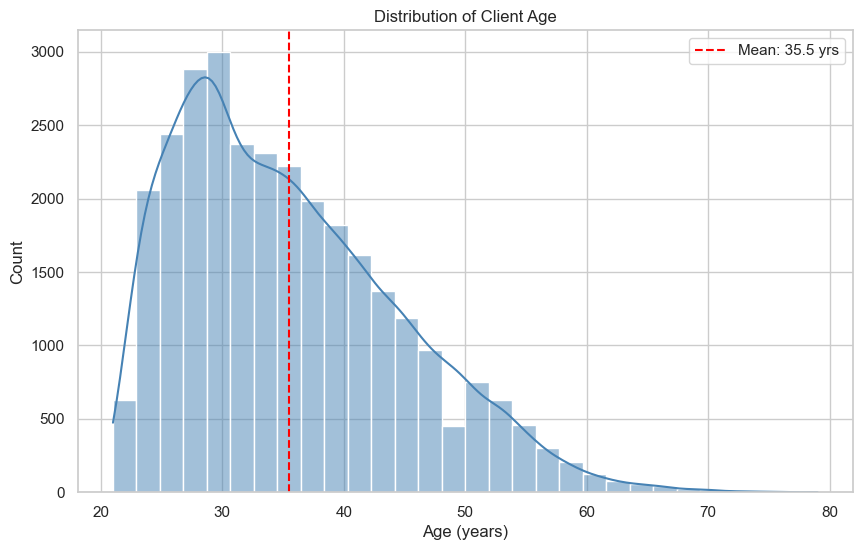

In [17]:
# Histogram of AGE variable
# This plot shows how customer ages are distributed across the dataset
# bins=30, kde=True, color="steelblue"
plt.figure(figsize=(10,6))

age_mean = UCI_Credit_Card["AGE"].mean()

sns.histplot(UCI_Credit_Card["AGE"], bins=30, kde=True, color="steelblue")
plt.axvline(age_mean, color="red", linestyle="--", label=f"Mean: {age_mean:.1f} yrs")

plt.title("Distribution of Client Age")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.legend()

plt.show()

#### Interpretation:

The AGE distribution is positively skewed (right-skewed), with the highest concentration of customers between approximately **25 and 35 years old**. The peak appears around the late 20s to early 30s, indicating that most credit card holders in this dataset belong to the younger working-age population. The mean customer age is approximately 35.5 years.

As age increases beyond 40 years, the number of customers gradually declines, and only a small proportion of customers are above 60 years old. This suggests that older individuals are less represented in the dataset.

The absence of unusual spikes or gaps indicates that the AGE variable is
reasonably well distributed and does not appear to contain major data
quality issues. Financial behaviour and repayment patterns often differ
across age groups, making AGE a potentially useful feature for prediction.


### Plot 2 — Distribution of Credit Limit

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


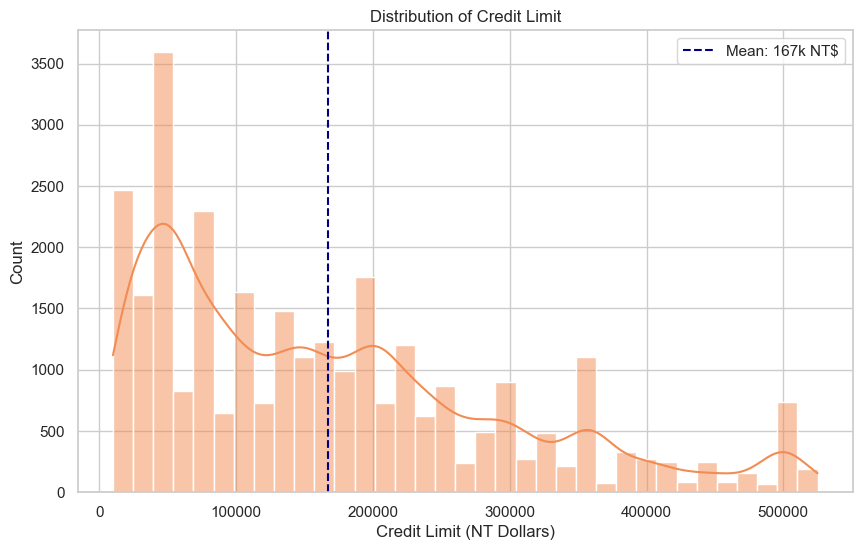

In [18]:
# Histogram of LIMIT_BAL
# This variable represents the amount of given credit in NT dollars

plt.figure(figsize=(10,6))

limit_mean = UCI_Credit_Card["LIMIT_BAL"].mean()

sns.histplot(UCI_Credit_Card["LIMIT_BAL"], bins=35, kde=True, color="#F28C52")
plt.axvline(limit_mean, color="navy", linestyle="--", label=f"Mean: {limit_mean/1000:.0f}k NT$")

plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit (NT Dollars)")
plt.ylabel("Count")
plt.legend()

plt.show()

#### Interpretation: Distribution of Credit Limit

This histogram shows the distribution of customer credit limits **LIMIT_BAL**. The variable is positively skewed, with a large concentration of customers holding relatively lower to medium credit limits, while fewer customers have very high limits.

The mean credit limit is approximately 167k NT dollars, shown by the dashed vertical line. Since the mean lies to the right of the main concentration, it confirms the presence of higher-value customers pulling the average upward.

Several peaks are visible, suggesting that credit limits may be assigned in standard bands rather than continuous values. This is common in financial products where credit limits are allocated in tiers.

Overall, credit limit appears to be an important financial feature with
substantial variation across customers, making it a potentially meaningful
variable for understanding default behaviour.

### Plot 3 — Education Level Distribution

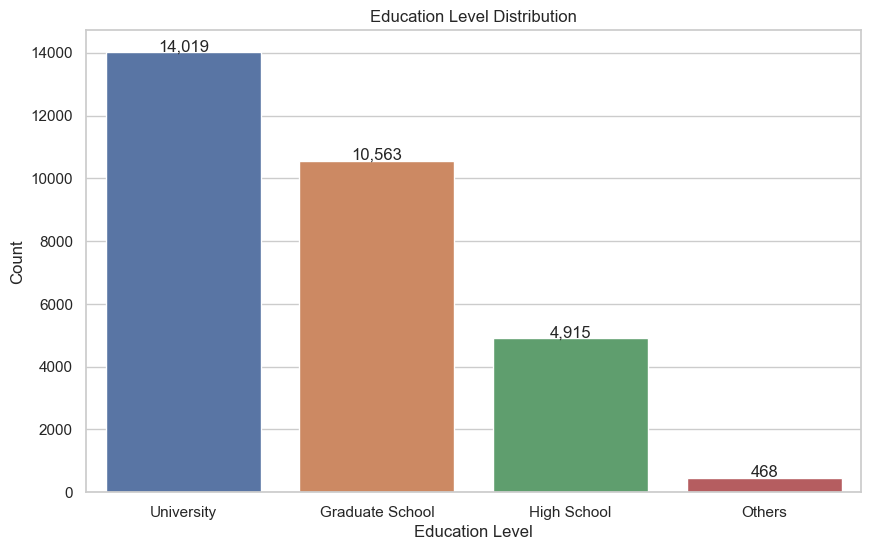

In [19]:
# Count plot for EDUCATION categories
plt.figure(figsize=(10,6))

edu_counts = UCI_Credit_Card["EDUCATION"].value_counts()

ax = sns.barplot(x=edu_counts.index, y=edu_counts.values, palette="deep")

plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")

for i, v in enumerate(edu_counts.values):
    ax.text(i, v + 30, f"{v:,}", ha="center")

plt.show()

#### Interpretation : Education Level Distribution

This chart presents the frequency of customers across education levels. The largest group consists of University customers (14,019), followed by Graduate School customers (10,563). High School customers represent a smaller but still meaningful group (4,915), while the Others category contains only 468 customers.

This indicates that the dataset is dominated by customers with tertiary education, suggesting that the customer base largely consists of relatively educated borrowers. The imbalance across categories should be considered when interpreting subgroup comparisons.

For modelling purposes, education level may offer useful demographic segmentation, although rare categories such as Others may require careful handling due to limited observations.

### Plot 4 — Marital Status Distribution

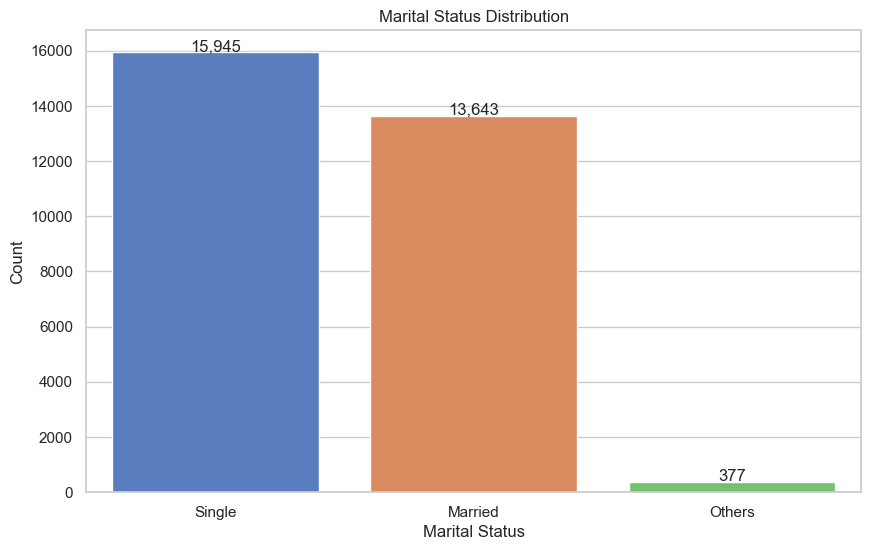

In [20]:
# Count plot for marriage categories

plt.figure(figsize=(10,6))

mar_counts = UCI_Credit_Card["MARRIAGE"].value_counts()

ax = sns.barplot(x=mar_counts.index, y=mar_counts.values, palette="muted")

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")

for i, v in enumerate(mar_counts.values):
    ax.text(i, v + 30, f"{v:,}", ha="center")

plt.show()

#### Interpretation: Marital Status Distribution

This bar chart shows the number of customers in each marital status category. The majority of customers are Single (15,945), followed by Married customers (13,643). The Others category contains only 377 observations, making it a very small minority group.

The relatively balanced counts between Single and Married customers indicate that marital status is reasonably represented across the two main categories. However, the Others category is substantially underrepresented, which means any conclusions involving this group should be interpreted cautiously due to the smaller sample size.

From a modelling perspective, marital status may still provide useful demographic information, but categories with very low counts may contribute limited predictive power.

## 4.2 Two-Variable Plots

Two-variable plots are used to explore relationships between one explanatory variable and another variable, including the target variable. These plots help identify which features may be more strongly associated with default risk.

### Plot 5 — Default Rate by Education Level

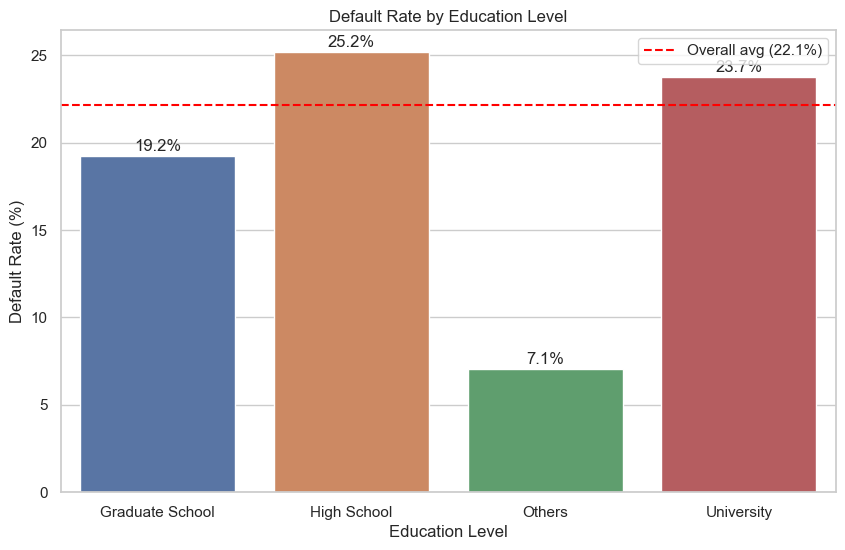

In [21]:
# barchart comparing educational levels with default rate

plt.figure(figsize=(10,6))

edu_default_rate = (
    UCI_Credit_Card.groupby("EDUCATION")["default.payment.next.month"].mean() * 100
)

overall_default_rate = UCI_Credit_Card["default.payment.next.month"].mean() * 100

ax = sns.barplot(x=edu_default_rate.index, y=edu_default_rate.values, palette="deep")

plt.axhline(overall_default_rate, color="red", linestyle="--",
            label=f"Overall avg ({overall_default_rate:.1f}%)")

plt.title("Default Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Default Rate (%)")
plt.legend()

for i, v in enumerate(edu_default_rate.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.show()

#### Interpretation : Default Rate by Education Level

This bar chart shows the percentage of customers who defaulted within each education category. The red dashed line represents the overall dataset default rate of approximately 22.1%, which provides a benchmark for comparison.

Customers in the High School category exhibit the highest default rate at 25.2%, followed closely by University customers at 23.7%. Both groups are above the overall average, suggesting that these education categories may have relatively higher repayment risk.

Graduate School customers show a lower default rate of 19.2%, which is below the dataset average. The Others category has the lowest default rate at 7.1%, although this group likely contains fewer observations and should therefore be interpreted cautiously.

Overall, the chart suggests that education level has some relationship
with default behaviour. However, the differences across groups are moderate
rather than extreme, indicating that education level alone may not be
sufficient to distinguish defaulters from non-defaulters and is likely
to work best in combination with other features.

### Plot 6 — Credit Limit by Default Status

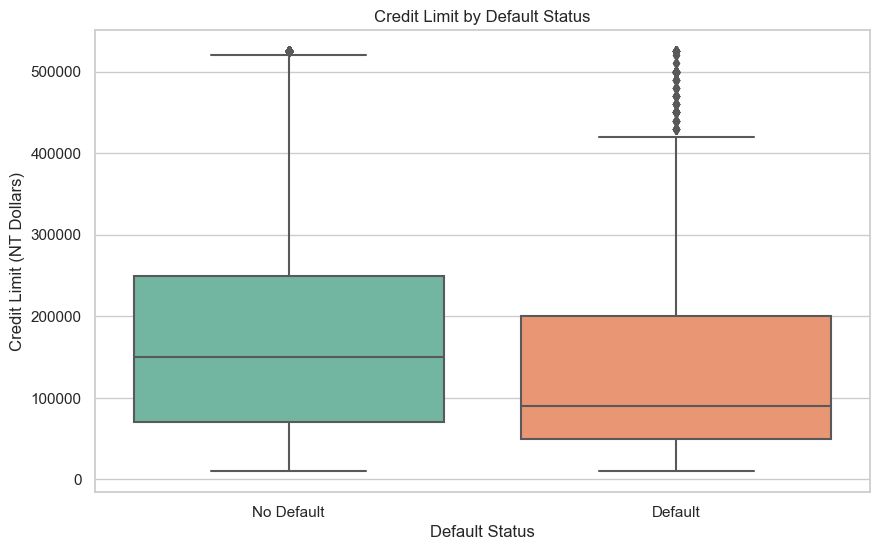

In [22]:
# Boxplot comparing credit limit across default groups

plt.figure(figsize=(10,6))

sns.boxplot(
    x="default.payment.next.month",
    y="LIMIT_BAL",
    data=UCI_Credit_Card,
    palette="Set2"
)

plt.title("Credit Limit by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Credit Limit (NT Dollars)")
plt.xticks([0,1], ["No Default","Default"])

plt.show()

#### Interpretation : Credit Limit by Default Status

This boxplot shows a clear difference between the two groups. Customers
who did not default have a higher median credit limit of around `NT$150,000`
compared to defaulting customers whose median is around `NT$100,000`.

The default group shows more high value outliers above the upper whisker,
suggesting some defaulting customers still hold relatively high credit limits.
Despite this, the overall credit limit tends to be lower for defaulting
customers, with both groups showing a similar lower range.

This suggests that `LIMIT_BAL` is a meaningful feature for understanding
default behaviour. Customers with lower credit limits appear more likely
to default, possibly reflecting a weaker financial profile or lower
creditworthiness.

### Plot 7 — Age Distribution by Default Status

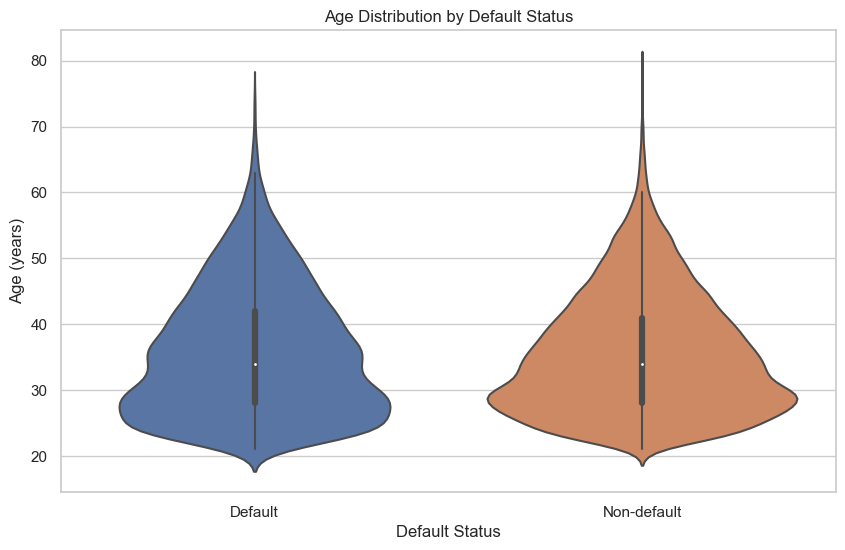

In [23]:
# Count plot of SEX split by default class

plt.figure(figsize=(10,6))

sns.violinplot(
    x=UCI_Credit_Card["default.payment.next.month"].map({0: "Non-default", 1: "Default"}),
    y=UCI_Credit_Card["AGE"],
    palette="deep",
    inner="box"
)

plt.title("Age Distribution by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Age (years)")

plt.show()

#### Intepretation : Age Distribution by Default Status

This violin plot compares the age distribution of customers who defaulted and those who did not default. The shape of each violin represents the density of observations, while the inner boxplot indicates the median and interquartile range.

The two distributions are highly similar, with both groups concentrated around the late 20s to late 30s. The median age for each group appears close to the mid-30s, and the spread of ages is also comparable. This suggests that age does not strongly differentiate defaulting customers from non-defaulting customers.

Although both groups include older customers, the majority of observations remain concentrated within the younger working-age population. From a predictive perspective, age may provide some supporting information, but it appears to be a weaker standalone predictor compared with behavioural or financial variables such as repayment history and credit limit.

### Plot 8 — Feature Correlation Heatmap

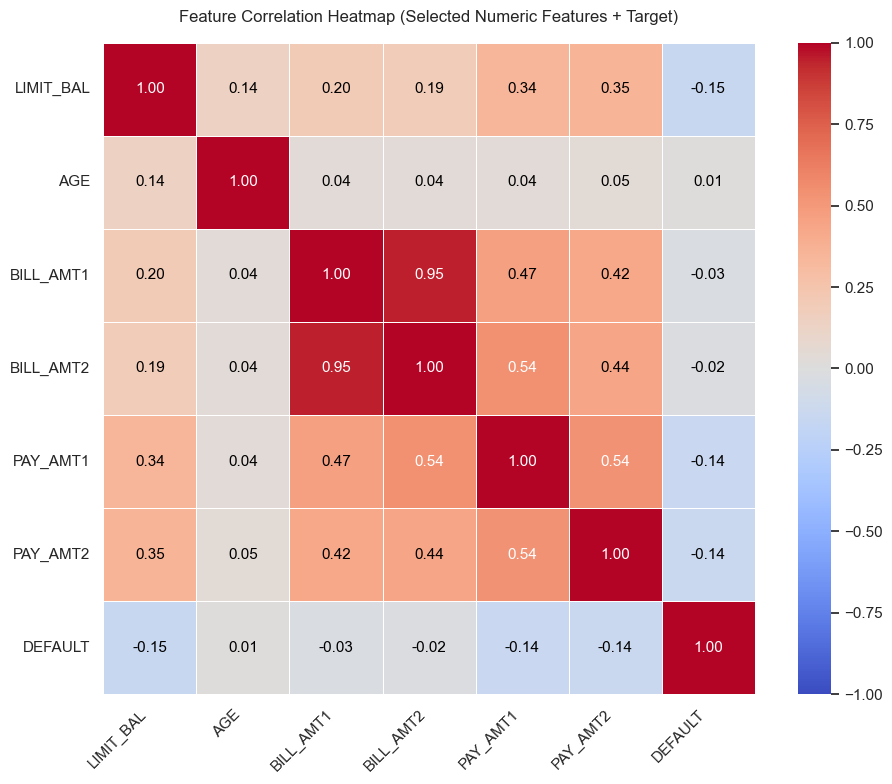

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Selected numeric columns
selected_cols = [
    'LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
    'PAY_AMT1', 'PAY_AMT2', 'default.payment.next.month'
]

# Correlation matrix
corr = UCI_Credit_Card[selected_cols].select_dtypes(include=['number']).corr()

corr = corr.rename(
    columns={"default.payment.next.month": "DEFAULT"},
    index={"default.payment.next.month": "DEFAULT"}
)

plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    corr,
    annot=False,          # turn off built-in annotations
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar=True
)

# Add annotations manually
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.iloc[i, j]
        
        # Choose text colour based on cell intensity
        text_color = "white" if abs(value) >= 0.5 else "black"
        
        ax.text(
            j + 0.5, i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=11
        )

plt.title("Feature Correlation Heatmap (Selected Numeric Features + Target)", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Intepretation: Feature Correlation Heatmap (Selected Numeric Features + Target)

This heatmap displays the linear correlation between selected numerical
variables and the target variable (`DEFAULT`). Correlation values range
from -1 to +1, where positive values indicate that variables move in
the same direction, while negative values indicate an inverse relationship.

The strongest relationship among explanatory variables is between `BILL_AMT1`
and `BILL_AMT2` (0.95), which is expected as bill amounts in consecutive months
tend to be very similar. `PAY_AMT1` and `PAY_AMT2` also show a strong positive
relationship (0.54), suggesting customers who make larger payments in one
month tend to do so in the following month as well.

With respect to DEFAULT, `LIMIT_BAL` has the strongest relationship at -0.15,
meaning customers with higher credit limits are slightly less likely to
default. `PAY_AMT1` and `PAY_AMT2` both show a correlation of -0.14 with
DEFAULT, suggesting higher recent payments are associated with lower
default risk. AGE shows almost no relationship with DEFAULT at 0.01.

Overall, the correlations with DEFAULT are relatively weak, indicating
that no single variable strongly explains default behaviour on its own.
This suggests that combining multiple features together will be important
for building an effective prediction model.

## 4.3 Three-Variable Plots

Three-variable plots are used to examine how multiple customer characteristics interact simultaneously with default behaviour. These visualisations provide deeper insight than one-variable and two-variable plots, as real-world financial risk is often influenced by a combination of demographic, behavioural, and financial factors.

### Plot 9 - Age vs Credit Limit (Colour = Default Status)

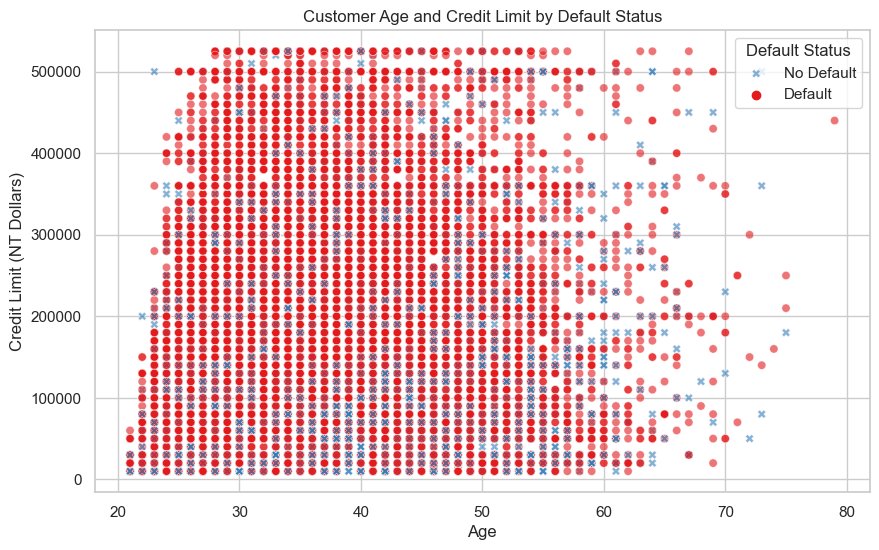

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="AGE",
    y="LIMIT_BAL",
    hue="default.payment.next.month",
    style="default.payment.next.month",
    data=UCI_Credit_Card,
    palette="Set1",
    alpha=0.6
)

plt.title("Customer Age and Credit Limit by Default Status")
plt.xlabel("Age")
plt.ylabel("Credit Limit (NT Dollars)")

plt.legend(title="Default Status", labels=["No Default","Default"])

plt.show()

#### Intepretation: Customer Age and Credit Limit by Default Status

This plot compares customer age, credit limit, and default status simultaneously. The two classes overlap considerably across both age and credit limit ranges, indicating that these two variables alone do not clearly separate defaulters from non-defaulters.

Most customers are concentrated between ages 25 and 50, with a wide spread of credit limits. Default customers appear across all age groups, suggesting that age by itself is not a strong determinant of default behaviour.

Credit limit shows somewhat more variation between groups than age, but substantial overlap remains. This implies that while credit limit may contribute useful predictive information, it is unlikely to be sufficient as a standalone feature.

Overall, the plot suggests that demographic variables such as age are weaker predictors compared with behavioural features like repayment status, and that multiple variables must be combined to effectively predict default risk.

### Plot 10: Bill Amount (Sep) vs Payment Amount (Sep) (Colour = Default Status)

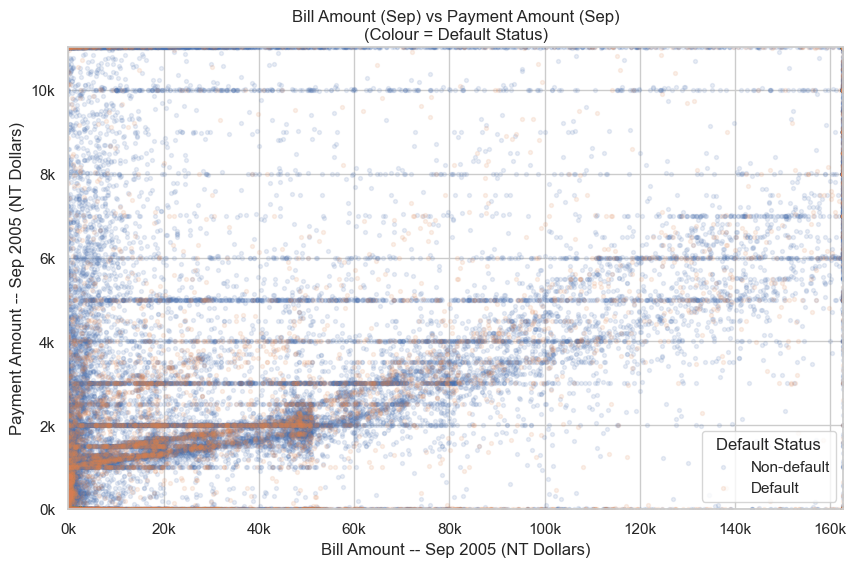

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

plt.figure(figsize=(10,6))

palette = {
    0: "#4C72B0",
    1: "#DD8452"
}

label_map = {
    0: "Non-default",
    1: "Default"
}

# Define upper display limits using percentiles
x_max = UCI_Credit_Card["BILL_AMT1"].quantile(0.99)
y_max = UCI_Credit_Card["PAY_AMT1"].quantile(0.99)

for status, grp in UCI_Credit_Card.groupby("default.payment.next.month"):
    plt.scatter(
        grp["BILL_AMT1"],
        grp["PAY_AMT1"],
        alpha=0.12,
        s=8,
        color=palette[status],
        label=label_map[status]
    )

plt.title("Bill Amount (Sep) vs Payment Amount (Sep)\n(Colour = Default Status)")
plt.xlabel("Bill Amount -- Sep 2005 (NT Dollars)")
plt.ylabel("Payment Amount -- Sep 2005 (NT Dollars)")

plt.xlim(0, x_max)
plt.ylim(0, y_max)

plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')
)
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda y, _: f'{y/1000:.0f}k')
)

plt.legend(title="Default Status")
plt.show()

#### Interpretation : Bill Amount (Sep) vs Payment Amount (Sep) (Colour = Default Status)

This scatterplot compares the September bill amount **BILL_AMT1**, September payment amount **PAY_AMT1**, and default status. A positive relationship is visible, where customers with larger outstanding bills often make larger payments. This is expected, as customers with higher balances generally need to make higher repayments. However, many observations are concentrated near lower payment values despite moderate or high bill amounts. These cases may represent financially stressed customers who are paying less than expected relative to their balance. The noticeable horizontal bands in the plot suggest that many customers
tend to make fixed round number payments regardless of their bill amount.

Default customers appear more frequently among customers with lower payment amounts relative to their bill size, suggesting that payment behaviour provides meaningful signals of future repayment risk. Although there is overlap between the two classes, this plot indicates that bill and payment variables may be useful predictors when combined with repayment history variables.


### Plot 11- Default Rate by Education Level and Gender

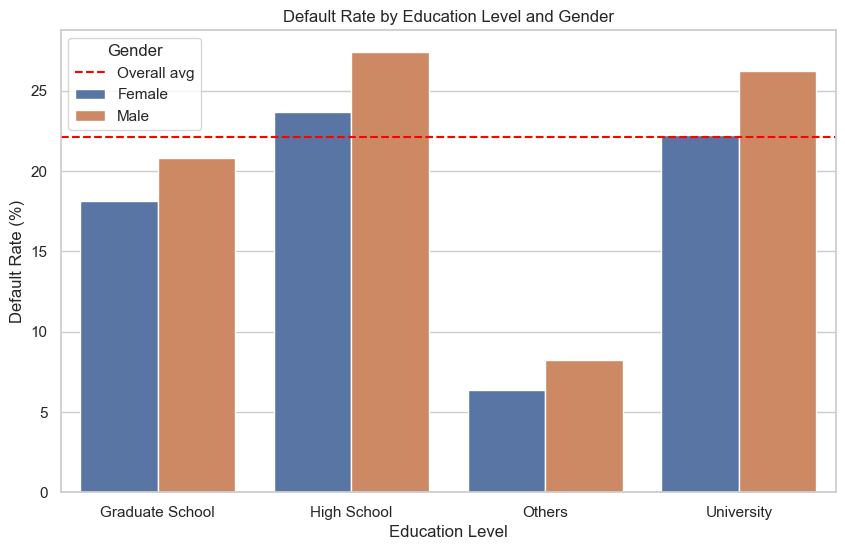

In [27]:
plt.figure(figsize=(10,6))

temp = UCI_Credit_Card.copy()

edu_gender_default = (
    temp.groupby(["EDUCATION", "SEX"])["default.payment.next.month"]
    .mean()
    .reset_index()
)

edu_gender_default["default_rate"] = edu_gender_default["default.payment.next.month"] * 100

ax = sns.barplot(
    data=edu_gender_default,
    x="EDUCATION",
    y="default_rate",
    hue="SEX"
)

plt.axhline(overall_default_rate, color="red", linestyle="--", label="Overall avg")

plt.title("Default Rate by Education Level and Gender")
plt.xlabel("Education Level")
plt.ylabel("Default Rate (%)")
plt.legend(title="Gender")

plt.show()

#### Intepretation: Default Rate by Education Level and Gender

This grouped bar chart shows how default rates vary jointly across education level and gender. Customers in the High School category display the highest default rates for both males and females, with male customers in this category showing the highest overall rate.

University customers also exhibit above-average default rates, while Graduate School customers show comparatively lower default rates. The Others category has the lowest default rates, although this group likely contains fewer observations and should therefore be interpreted cautiously.

Across most education categories, male customers show a slightly higher default rate than female customers. This suggests that gender may contribute some additional predictive value when combined with education level.

Overall, the plot indicates that demographic variables may have moderate explanatory value, but their influence appears weaker than behavioural variables such as repayment status.

### Plot 12 - Recent Repayment + Credit Limit + Default

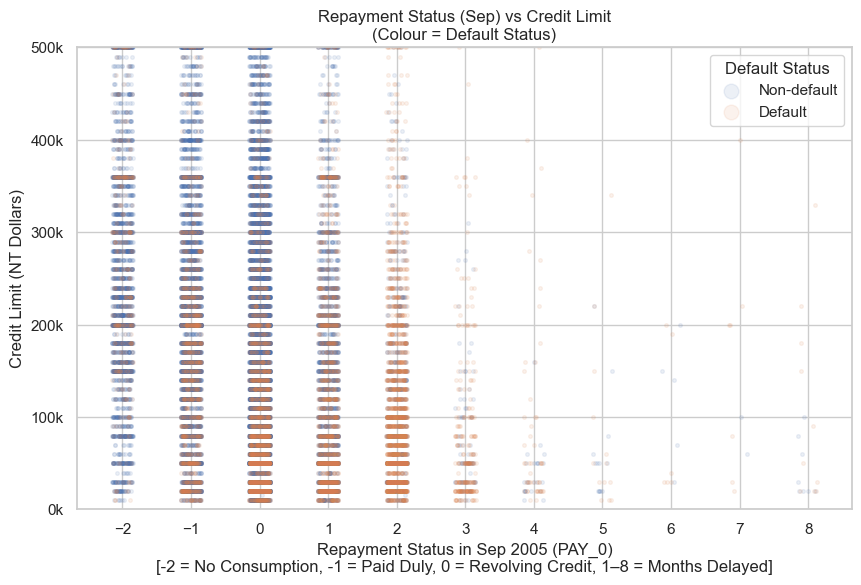

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Make a copy so the original labelled dataframe stays unchanged
plot_df = UCI_Credit_Card.copy()

# Convert labelled repayment status back to numeric for plotting
pay_reverse_map = {
    "No Consumption": -2,
    "Paid Duly": -1,
    "Revolving Credit": 0,
    "1 Month Delay": 1,
    "2 Month Delay": 2,
    "3 Month Delay": 3,
    "4 Month Delay": 4,
    "5 Month Delay": 5,
    "6 Month Delay": 6,
    "7 Month Delay": 7,
    "8 Month Delay": 8
}

plot_df["PAY_0_NUM"] = plot_df["PAY_0"].replace(pay_reverse_map)

# Remove rows where mapping failed, just in case
plot_df = plot_df.dropna(subset=["PAY_0_NUM", "LIMIT_BAL", "default.payment.next.month"])

# Make sure PAY_0_NUM is numeric
plot_df["PAY_0_NUM"] = plot_df["PAY_0_NUM"].astype(float)

palette = {
    0: "#4C72B0",
    1: "#DD8452"
}

label_map = {
    0: "Non-default",
    1: "Default"
}

rng = np.random.default_rng(42)

# Limit display range for better readability
y_max = plot_df["LIMIT_BAL"].quantile(0.99)

plt.figure(figsize=(10,6))

for status, grp in plot_df.groupby("default.payment.next.month"):
    jitter = rng.uniform(-0.15, 0.15, size=len(grp))

    plt.scatter(
        grp["PAY_0_NUM"] + jitter,
        grp["LIMIT_BAL"],
        alpha=0.10,
        s=7,
        color=palette[status],
        label=label_map[status]
    )

plt.title("Repayment Status (Sep) vs Credit Limit\n(Colour = Default Status)")
plt.xlabel("Repayment Status in Sep 2005 (PAY_0)\n[-2 = No Consumption, -1 = Paid Duly, 0 = Revolving Credit, 1–8 = Months Delayed]")
plt.ylabel("Credit Limit (NT Dollars)")

plt.xticks(sorted(plot_df["PAY_0_NUM"].unique()))
plt.ylim(0, y_max)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")
)

plt.legend(markerscale=4, title="Default Status")
plt.show()

#### Repayment Status (Sep) vs Credit Limit (Colour = Default Status)

This plot compares recent repayment behaviour **PAY_0**, customer credit limit **LIMIT_BAL**, and next month default status. Customers with repayment statuses of **-2**, **-1**, and **0** are more heavily concentrated in the non-default group, indicating that customers who made timely payments or used revolving credit were less likely to default.

As repayment delay increases to values such as **1**, **2**, and above, the proportion of default customers becomes noticeably higher. This suggests that worsening recent repayment behaviour is strongly associated with increased future default risk.

The plot also shows that both defaulting and non-defaulting customers exist across a broad range of credit limits. Therefore, credit limit alone does not determine default outcome. However, when combined with repayment status, it provides useful context for identifying higher-risk customers.

Overall, this is one of the most informative plots in the analysis, highlighting that recent repayment history is likely to be one of the strongest predictors for Phase 2 modelling.

# 5 Literature Review

### Section 1: Why credit card matters?
Credit card default prediction is one of the most consequential and detailed studied problems in the finance. The rapid increase of the credit card industry over the past two decades has been contributed by a rise in delinquency rates, financial growth pressure by commercial banks and exposing border economics (Yu et al., 2020). The Taiwan credit card crisis of 2005 in which banks aggressively over-issued credit cards to unqualified applicants. The combination of adverse borrower selection and information asymmetry can destabilise an entire national credit market. (Yeh & Lien, 2009). Similar dynamics played out at a global scale during the American subprime mortgage crisis, expanded through interconnected financial systems and inflicted widespread economic damage (Yu et al., 2020). These events collectively illustrate that the ability to identify high risk borrowers before default occurs is not just commercial imperative. It is a matter of stability in financial domain.
Traditional credit assessment framework includes manual judgement and widely used FICO scoring model have proven incompatibility for this. These approaches rely heavily on subjective professional opinion, resulting in low efficiency, inconsistent outcomes, and an inability to process the data at scale (Yu et al., 2020). The inadequacy has driven a shift toward machine learning approaches that employs the UCI default of Credit Card Client dataset introduced by Yeh and Lien (2009) to evaluate predictive modelling approaches on real-world financial data.

### Section 2: What has already been tried on such data?
The UCI Default of Credit Card Clients dataset has been studies by many researchers for evaluating classification algorithms in the credit risk domain. Yeh and Lien (2009) applied six data mining techniques to the dataset including regression, discriminant analysis and ANN to find the most probabilistic estimate of default.
Apart from this, Hu and Yeo (2024) evaluated machine learning algorithms on the Taiwan dataset and find out that SVM classifier achieved the highest accuracy at 82.03%, while also demonstrating that feature scaling techniques improved model performance. More recently, Abubakar et al. (2025) analysed a comprehensive comparison of six models including XGBoost, random forest and deep neural network ML methods outperformed traditional statistical approaches across matrices like F1 score, G-mean and AUC.
Beyond this specific dataset, critical work has shaped the expectation for algorithm performance in credit scoring. Lessmann et al. (2015) performed large scale evaluation of 41 classifier across eight real world credit datasets. Louzada et al. (2016), in a systematic review of classification methods in credit scoring conducted that no single algorithm dominates across all contexts and need of comparative evaluation.

### Section 3: The challenge of class imbalance
The fundamental challenge in the credit default prediction is the severe imbalance between defaulters and non-defaulters in real-world. In the UCI Taiwan dataset specifically, approximately 22% of clients defaulted while the rest 78% did not. This causes the standard classifier to under detect the defaults class (Subasi & Cankurt, 2019). They test seven data mining algorithms under different mechanisms. Without any balancing, default class accuracy across all models were around 34-39%. Alam et al. (2020) found the similar accuracy on the Taiwan data increases from 66.9% to 89.01% after k-means SMOTE with gradient boost decision tree.

### Section 4: Important features
Not all the feature variables in the dataset equally contribute to predicting default and understanding which features creates impact on prediction has been a consistent focus in the literature. Ayogu et al. (2022) analyses the usefulness of demographic features specifically like gender, age, education, marital status and employment in credit default datasets and finds that the information gains improved decision tree accuracy by 24.56% but only demographic features were insufficient for granting decisions.
Butaru et al. (2016) reinforce this as an institutional perspective by stating six major commercial banks that payment behaviour and credit utilisation variables are most impactful in delinquency prediction. This maps directly onto the variables in the Taiwan dataset like, repayment status (X6-X11), bill statement amounts (X12-X17), and payment amounts (X18-X23) capture six months of dynamic financial behaviour rather than static characteristic. Khandani and Lo (2010) argues that dynamic transactional data outperforms static borrower profiles in consumer credit risk modelling. Overall, these findings suggest that the payment history variables in the dataset dictate the attention during both exploratory analysis and feature selection.

### Section 5: Where this field is going
The credit default prediction literature has moved progressively from classical old statistical models to ensemble methods, deep learning architecture and scalable pipelines. Chen and Qiu (2024) evaluated logistic regression, random forest across two different datasets. Their results shows that a fine-tuned neural network achieved the highest accuracy suggesting data scale and feature engineering matters more than algorithm selection. Chang et al. (2018) established XGBoost as an effective tool for credit risk assessment and its superiority over traditional models through its ability to handle non-linear features efficiently. Karatas et al. (2024) stated that deep learning models continues to push the model performance boundaries, though interpretability still remains a challenge for institutional adoption.
So, the present study operates at the classical ML stage of the trajectory by applying, performing and comparing algorithms on Taiwan dataset while keeping in mind that ensemble methods and deep learning approach the current frontier.


# 6. Summary & Conclusions

Phase 1 of this project focused on preparing and exploring the UCI
Default of Credit Card Clients Dataset in order to build a solid
foundation for predictive modelling. The following summarises the key
steps taken and the insights gained.

**Data Cleaning & Preprocessing**

The dataset originally contained 30,000 observations and 25 features.
The ID column was removed as it carried no predictive value, leaving 24
features for analysis. No missing values were found across any column,
which is a notable advantage for this dataset. However, 35 duplicate
rows were identified and removed, bringing the final dataset to 29,965
observations.

Undocumented category values were found in both EDUCATION (values 0, 5,
and 6) and MARRIAGE (value 0). These were consolidated into the Others
category to preserve all observations while maintaining data integrity.
Categorical variables such as repayment status were also recoded with
meaningful labels to improve readability. Age values were confirmed to
fall within a realistic range of 21 to 79 years, and negative bill
amounts were identified as valid overpayment entries and retained.
Outliers were detected across all financial columns using the 1.5 x IQR
method and capped at fence values to reduce their influence without
losing any rows.

**Data Exploration & Visualisation**

The exploratory analysis revealed several important patterns in the data:

- The dataset is imbalanced, with approximately 77.9% non-defaulters
  and 22.1% defaulters. This will need to be addressed during modelling.
- Most clients fall between the ages of 25 and 40, with the age
  distribution being right-skewed.
- Credit limit is right-skewed with a mean of approximately NT$167,000.
  Clients with lower credit limits are more likely to default.
- University educated clients make up the largest group, and high school
  educated clients show the highest default rate at 25.2%.
- Single clients form the largest marital status group, with a similar
  default rate to married clients.
- Male clients show slightly higher default rates than female clients
  across all education levels.
- Recent repayment status (PAY_0) is the strongest indicator of default
  behaviour. Clients with payment delays are significantly more likely
  to default.
- Non-defaulting clients consistently make higher payment amounts across
  all six months compared to defaulting clients.
- Bill amounts in consecutive months are highly correlated, which may
  require careful handling during feature selection.

**Overall Insights**

The analysis confirms that behavioural features, particularly repayment
history and payment amounts, are more strongly associated with default
risk than demographic features such as age and education. Credit limit
also provides meaningful separation between the two groups. The dataset
is now clean, well understood, and ready for the predictive modelling
stage in Phase 2.

# 7 References

### Articles:
1.	Yeh, I.-C., & Lien, C.-H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473–2480. https://doi.org/10.1016/j.eswa.2007.12.020
2.	Dua, D., & Graff, C. (2019). UCI Machine Learning Repository. University of California, Irvine, School of Information and Computer Sciences. https://archive.ics.uci.edu/
3. UCI ML. (n.d.). *Default of Credit Card Clients Dataset*. Kaggle. https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
4.	Alam, T. M., Shaukat, K., Hameed, I. A., Luo, S., Sarwar, M. U., Shabbir, S., Li, J., & Khushi, M. (2020). An Investigation of Credit Card Default Prediction in the Imbalanced Datasets. IEEE Access, 8, 201173–201198. https://doi.org/10.1109/access.2020.3033784
5.	Butaru, F., Chen, Q., Clark, B., Das, S., Lo, A. W., & Siddique, A. (2016). Risk and risk management in the credit card industry. Journal of Banking & Finance, 72, 218–239. https://doi.org/10.1016/j.jbankfin.2016.07.015
6.	Chang, Y.-C., Chang, K.-H., & Wu, G.-J. (2018). Application of eXtreme gradient boosting trees in the construction of credit risk assessment models for financial institutions. Applied Soft Computing, 73, 914–920. https://doi.org/10.1016/j.asoc.2018.09.029
7.	Bhandary, R., & Ghosh, B. K. (2025). Credit Card Default Prediction: An Empirical Analysis on Predictive Performance Using Statistical and Machine Learning Methods. Journal of Risk and Financial Management, 18(1), 23. https://doi.org/10.3390/jrfm18010023
8.	Chang, V., Sivakulasingam, S., Wang, H., Wong, S. T., Ganatra, M. A., & Luo, J. (2024). Credit Risk Prediction Using Machine Learning and Deep Learning: A Study on Credit Card Customers. Risks, 12(11), 174. https://doi.org/10.3390/risks12110174
9.	Louzada, F., Ara, A., & Fernandes, G. B. (2016). Classification methods applied to credit scoring: A systematic review and overall comparison. ArXiv:1602.02137 [Stat]. https://arxiv.org/abs/1602.02137
10.	Khandani, A. E., Kim, A. J., & Lo, A. W. (2010). Consumer credit-risk models via machine-learning algorithms. Journal of Banking & Finance, 34(11), 2767–2787. https://doi.org/10.1016/j.jbankfin.2010.06.001
11.	Dastile, X., Celik, T., & Potsane, M. (2020). Statistical and machine learning models in credit scoring: A systematic literature survey. Applied Soft Computing, 91, 106263. https://doi.org/10.1016/j.asoc.2020.106263

### Conference Papers:
12.	Hu, Z., & Yeo, C. K. (2024). A Lightweight Neural Network with Transformer to Predict Credit Default. 2024 IEEE Conference on Artificial Intelligence (CAI), 29–30. https://doi.org/10.1109/cai59869.2024.00015
13.	Subasi, A., & Cankurt, S. (2019, June 1). Prediction of default payment of credit card clients using Data Mining Techniques. IEEE Xplore. https://doi.org/10.1109/IEC47844.2019.8950597
14.	Ayogu, I. I., PopoOla, O. S., MebawOndu, O. J., Ugwu, C. C., & Adetunmbi, A. O. (2022). Performance Evaluation of Feature Selection Techniques for Credit Default Prediction. 2022 IEEE Nigeria 4th International Conference on Disruptive Technologies for Sustainable Development (NIGERCON), 1–5. https://doi.org/10.1109/nigercon54645.2022.9803064
15.	Yu, Y. (2020, August 1). The Application of Machine Learning Algorithms in Credit Card Default Prediction. IEEE Xplore. https://doi.org/10.1109/CDS49703.2020.00050
16.	Chen, A., & Qiu, Y. (2024). Deep Learning and Machine Learning Models for Scalable Credit Card Default Prediction on Big Data. 2021 IEEE International Conference on Big Data (Big Data), 7292–7296. https://doi.org/10.1109/bigdata62323.2024.10825743
